## Kiểm tra ảnh lỗi


In [3]:
from PIL import Image
import os

dataset_path = r"D:\KÌ 7\RiceDataset_Final"

bad_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:

        if not file.lower().endswith(
            ('.jpg','.jpeg','.png','.bmp','.webp')
        ):
            continue

        path = os.path.join(root,file)

        try:
            img = Image.open(path)
            img.verify()

        except Exception:
            bad_images.append(path)

print("Bad images:", len(bad_images))

for img in bad_images[:20]:
    print(img)

Bad images: 0


## Kiểm tra ảnh trùng

In [4]:
import os
from PIL import Image
import imagehash

dataset_path = r"D:\KÌ 7\RiceDataset_Final"

hashes = {}
duplicates = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if not file.lower().endswith(
            ('.jpg','.jpeg','.png','.bmp','.webp')
        ):
            continue

        path = os.path.join(root,file)

        try:
            h = str(
                imagehash.average_hash(
                    Image.open(path)
                )
            )

            if h in hashes:
                duplicates.append(
                    (path, hashes[h])
                )

            else:
                hashes[h] = path

        except:
            pass

print("Duplicates:", len(duplicates))

Duplicates: 2995


In [5]:
import shutil



# --- THÊM ĐOẠN NÀY ĐỂ DI CHUYỂN ---
trash_folder = r"D:\KÌ 7\Duplicated_Trash"

# Tạo thư mục thùng rác nếu chưa có
if not os.path.exists(trash_folder):
    os.makedirs(trash_folder)

moved_count = 0
for dup_path, orig_path in duplicates:
    try:
        # Lấy tên file gốc để cho vào thư mục rác
        file_name = os.path.basename(dup_path)
        destination = os.path.join(trash_folder, file_name)
        
        # Di chuyển file
        shutil.move(dup_path, destination)
        moved_count += 1
    except Exception as e:
        print(f"Lỗi khi di chuyển {dup_path}: {e}")

print(f"Đã cách ly an toàn {moved_count} ảnh vào thư mục {trash_folder}.")

Đã cách ly an toàn 2995 ảnh vào thư mục D:\KÌ 7\Duplicated_Trash.


## Tạo metadata.csv

In [6]:
import os
import pandas as pd

dataset_path = r"D:\KÌ 7\RiceDataset_Final"

rows = []

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):

        if not file.lower().endswith(
            ('.jpg','.jpeg','.png')
        ):
            continue

        rows.append([
            os.path.join(class_path,file),
            cls
        ])

df = pd.DataFrame(
    rows,
    columns=["image_path","label"]
)

df.to_csv(
    "../data/metadata.csv",
    index=False
)

print(df.shape)

(16659, 2)


## Vẽ Distribution Chart

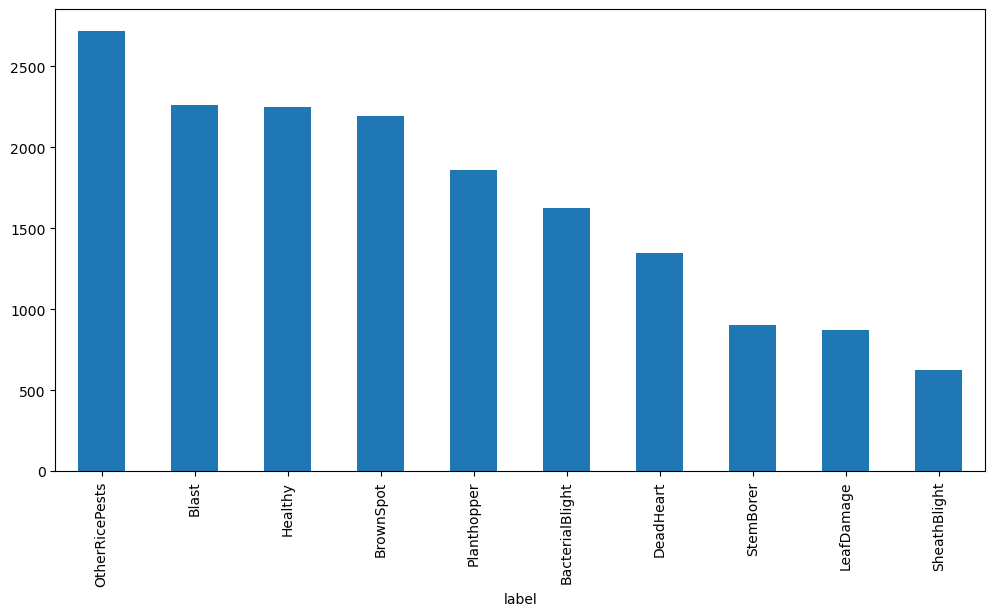

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/metadata.csv")

df["label"].value_counts().plot(
    kind="bar",
    figsize=(12,6)
)

plt.show()

In [8]:
plt.savefig("../results/class_distribution.png")

<Figure size 640x480 with 0 Axes>

## Tính Class Weight

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(df["label"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df["label"]
)

for c,w in zip(classes,weights):
    print(c,w)

BacterialBlight 1.0226519337016575
Blast 0.7367978770455551
BrownSpot 0.7599908759124088
DeadHeart 1.237667161961367
Healthy 0.7400710795202132
LeafDamage 1.9060640732265446
OtherRicePests 0.6131394920868605
Planthopper 0.8946831364124597
SheathBlight 2.66544
StemBorer 1.8468957871396896


In [ ]:
# import os
# import random
# import matplotlib.pyplot as plt
# from PIL import Image

# dataset_path = r"D:\KÌ 7\RiceDataset_Final"
# samples_per_class = 5

# # Lấy danh sách các thư mục (mỗi thư mục tương ứng với một label/class)
# classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
# num_classes = len(classes)

# print(f"Đang xử lý hiển thị mẫu cho {num_classes} lớp bệnh...")

# # Khởi tạo bảng grid (số hàng = số class, số cột = 5)
# # Kích thước khung hình (figsize) được tùy chỉnh tự động theo số lượng class
# fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(15, 3 * num_classes))

# # Đảm bảo axes luôn là mảng 2 chiều để dễ duyệt qua (phòng trường hợp chỉ có 1 class)
# if num_classes == 1:
#     axes = [axes]

# for i, cls in enumerate(classes):
#     cls_path = os.path.join(dataset_path, cls)
    
#     # Lấy danh sách tất cả ảnh trong class hiện tại
#     all_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
    
#     # Bốc ngẫu nhiên (tối đa 5 ảnh, đề phòng trường hợp thư mục có ít hơn 5 ảnh)
#     sampled_files = random.sample(all_files, min(samples_per_class, len(all_files)))
    
#     for j in range(samples_per_class):
#         ax = axes[i][j]
#         ax.axis('off') # Tắt trục tọa độ x, y cho dễ nhìn
        
#         if j < len(sampled_files):
#             img_path = os.path.join(cls_path, sampled_files[j])
#             try:
#                 # Đọc và hiển thị ảnh
#                 img = Image.open(img_path)
#                 ax.imshow(img)
                
#                 # In tên file ở dưới mỗi ảnh (rút gọn nếu tên quá dài)
#                 file_name = sampled_files[j][:15] + "..." if len(sampled_files[j]) > 15 else sampled_files[j]
#                 ax.set_title(file_name, fontsize=8)
                
#                 # In tên Class ở bức ảnh đầu tiên của mỗi hàng
#                 if j == 0:
#                     ax.text(-0.1, 0.5, cls, fontsize=12, fontweight='bold', 
#                             va='center', ha='right', transform=ax.transAxes)
#             except Exception as e:
#                 ax.set_title("Lỗi đọc ảnh", color='red')
#         else:
#             # Nếu không đủ 5 ảnh, để trống ô đó
#             pass

# plt.tight_layout()
# plt.show()

: 